In [1]:
import torch
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import yfinance as yf
from datetime import datetime, timedelta
from dotenv import load_dotenv
from scipy.special import softmax
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import os

load_dotenv()
api_key = os.environ.get("NEWS_API_KEY")

C:\Users\sonny\anaconda3\envs\project_finance\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# NEW API

In [2]:
# Define the request
query = "European stock market OR Eurostoxx OR CAC40 OR DAX OR European equities"
url = f"https://newsapi.org/v2/everything?q={query}&apiKey={api_key}&language=en&sortBy=publishedAt&pageSize=100"
response = requests.get(url)

# Get data 
results = []
if response.status_code == 200:
    news_data = response.json()
    for article in news_data["articles"]:
        results.append({
            "Date": article["publishedAt"][:10],  # Extract date
            "URL": article["url"],
            "Source": article["source"]['name'],
            "Author": article["author"],
            "Title": article["title"],
            "Description": article["description"],
            "Content": article["content"]
        })
else:
    print("Error fetching news:", response.status_code)

df = pd.DataFrame(results)
df.to_csv("European_Market_news.csv", index=False)
df

,Date,URL,Source,Author,Title,Description,Content
0,2026-06-05,https://www.globenewswire.com/news-release/202...,GlobeNewswire,Euronext Paris SA,Euronext announces volumes for May 2026,Euronext announces volumes for May 2026 Amste...,Euronext announces volumes for May 2026\r\nAms...
1,2026-06-05,https://en.protothema.gr/2026/06/05/new-party-...,Protothema.gr,Newsroom,"New party secretary Kostas Kyranakis, Voridis ...","SpaceX threatens Cosmote, Vodafone, Nova and a...","Hello, then. The latest hot-off-the-press news..."
2,2026-06-04,https://www.coindesk.com/opinion/2026/06/04/wh...,CoinDesk,Michael Lie,Why tokenization is an ETF-style market struct...,The current tokenization dialogue and pattern ...,"In the 1990s, exchange-traded funds (ETFs) wer..."
3,2026-06-04,https://www.ibtimes.com.au/dow-jones-surges-jo...,Ibtimes.com.au,Tony Jackson,"Dow Surges 686 Points to 51,373 as Strong Jobs...",The Dow Jones Industrial Average rose 686.23 p...,NEW YORK — The Dow Jones Industrial Average cl...
4,2026-06-04,https://www.thehindubusinessline.com/markets/s...,BusinessLine,"Team BL, KS Badri Narayanan",Sensex today | Stock Market Highlights: Sensex...,"Sensex, Nifty, Stock Price Highlights: After a...","<li></li>\r\nJune 4, 2026 16:06Rupee closes ma..."
...,...,...,...,...,...,...,...
87,2026-05-15,https://www.prnewswire.co.uk/news-releases/byb...,PR Newswire UK,NaN,Bybit Unites Crypto and Traditional Finance in...,"DUBAI, UAE, May 15, 2026 /PRNewswire/ -- Bybit...","DUBAI, UAE, May 15, 2026 /PRNewswire/ -- Bybit..."
88,2026-05-15,https://www.prnewswire.com/news-releases/bybit...,PRNewswire,NaN,Bybit Unites Crypto and Traditional Finance in...,"DUBAI, UAE, May 15, 2026 /PRNewswire/ -- Bybit...","DUBAI, UAE, May 15, 2026 /PRNewswire/ -- Bybit..."
89,2026-05-15,https://www.ibtimes.com.au/dow-jones-drops-400...,Ibtimes.com.au,Tony Jackson,"Dow Plunges 395 Points to 49,667 as Tech Sell-...",The Dow Jones fell nearly 400 points due to a ...,NEW YORK — The Dow Jones Industrial Average tu...
90,2026-05-15,https://www.ibtimes.com.au/asx-200-closes-lowe...,Ibtimes.com.au,Tony Jackson,"ASX 200 Dips 0.12% to 8,630.8 as Miners Offset...","The ASX 200 index closed slightly lower, impac...",SYDNEY — The S&amp;P/ASX 200 index closed mode...


# Sentiment Analysis 

## FinBert

In [3]:
# Specify the FinBERT model
MODEL = f"ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

# Text processing function
def preprocess(text):
    if text is None: # Handle None values by returning an empty string if text is None
        return ""
    new_text = []
    for t in text.split(" "):
        t = "" if t.startswith("#") and len(t) > 1 else t  # remove hashtags
        t = "" if t.startswith("@") and len(t) > 1 else t  # remove usernames
        t = "" if t.startswith("http") else t  # remove URLs
        new_text.append(t)
    return " ".join(new_text)

# Sentiment scoring function
def get_sentiment(text):
    text = preprocess(text)
    encoded_input = tokenizer(text, return_tensors='pt')
    output = model(**encoded_input)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    return {
        "positive": scores[0],
        "negative": scores[1],
        "neutral": scores[2]
    }

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 28637.36it/s]


In [4]:
# Remove rows with "[Removed]" or None in Description
df = df[df["Description"] != "[Removed]"]
df = df.dropna(subset=["Description"])

# Apply sentiment scoring to the 'description' column and create new columns
df.loc[:, "Sent_positive"] = df["Description"].apply(lambda x: get_sentiment(x)["positive"])
df.loc[:, "Sent_negative"] = df["Description"].apply(lambda x: get_sentiment(x)["negative"])
df.loc[:, "Sent_neutral"] = df["Description"].apply(lambda x: get_sentiment(x)["neutral"])
df

,Date,URL,Source,Author,Title,Description,Content,Sent_positive,Sent_negative,Sent_neutral
0,2026-06-05,https://www.globenewswire.com/news-release/202...,GlobeNewswire,Euronext Paris SA,Euronext announces volumes for May 2026,Euronext announces volumes for May 2026 Amste...,Euronext announces volumes for May 2026\r\nAms...,0.121192,0.011282,0.867526
1,2026-06-05,https://en.protothema.gr/2026/06/05/new-party-...,Protothema.gr,Newsroom,"New party secretary Kostas Kyranakis, Voridis ...","SpaceX threatens Cosmote, Vodafone, Nova and a...","Hello, then. The latest hot-off-the-press news...",0.033296,0.042166,0.924537
2,2026-06-04,https://www.coindesk.com/opinion/2026/06/04/wh...,CoinDesk,Michael Lie,Why tokenization is an ETF-style market struct...,The current tokenization dialogue and pattern ...,"In the 1990s, exchange-traded funds (ETFs) wer...",0.055437,0.022163,0.922400
3,2026-06-04,https://www.ibtimes.com.au/dow-jones-surges-jo...,Ibtimes.com.au,Tony Jackson,"Dow Surges 686 Points to 51,373 as Strong Jobs...",The Dow Jones Industrial Average rose 686.23 p...,NEW YORK — The Dow Jones Industrial Average cl...,0.944929,0.024343,0.030727
4,2026-06-04,https://www.thehindubusinessline.com/markets/s...,BusinessLine,"Team BL, KS Badri Narayanan",Sensex today | Stock Market Highlights: Sensex...,"Sensex, Nifty, Stock Price Highlights: After a...","<li></li>\r\nJune 4, 2026 16:06Rupee closes ma...",0.911686,0.065746,0.022567
...,...,...,...,...,...,...,...,...,...,...
87,2026-05-15,https://www.prnewswire.co.uk/news-releases/byb...,PR Newswire UK,NaN,Bybit Unites Crypto and Traditional Finance in...,"DUBAI, UAE, May 15, 2026 /PRNewswire/ -- Bybit...","DUBAI, UAE, May 15, 2026 /PRNewswire/ -- Bybit...",0.640660,0.008536,0.350803
88,2026-05-15,https://www.prnewswire.com/news-releases/bybit...,PRNewswire,NaN,Bybit Unites Crypto and Traditional Finance in...,"DUBAI, UAE, May 15, 2026 /PRNewswire/ -- Bybit...","DUBAI, UAE, May 15, 2026 /PRNewswire/ -- Bybit...",0.640660,0.008536,0.350803
89,2026-05-15,https://www.ibtimes.com.au/dow-jones-drops-400...,Ibtimes.com.au,Tony Jackson,"Dow Plunges 395 Points to 49,667 as Tech Sell-...",The Dow Jones fell nearly 400 points due to a ...,NEW YORK — The Dow Jones Industrial Average tu...,0.008809,0.967908,0.023283
90,2026-05-15,https://www.ibtimes.com.au/asx-200-closes-lowe...,Ibtimes.com.au,Tony Jackson,"ASX 200 Dips 0.12% to 8,630.8 as Miners Offset...","The ASX 200 index closed slightly lower, impac...",SYDNEY — The S&amp;P/ASX 200 index closed mode...,0.012567,0.964701,0.022732


## Visualizing Sentiment Scores

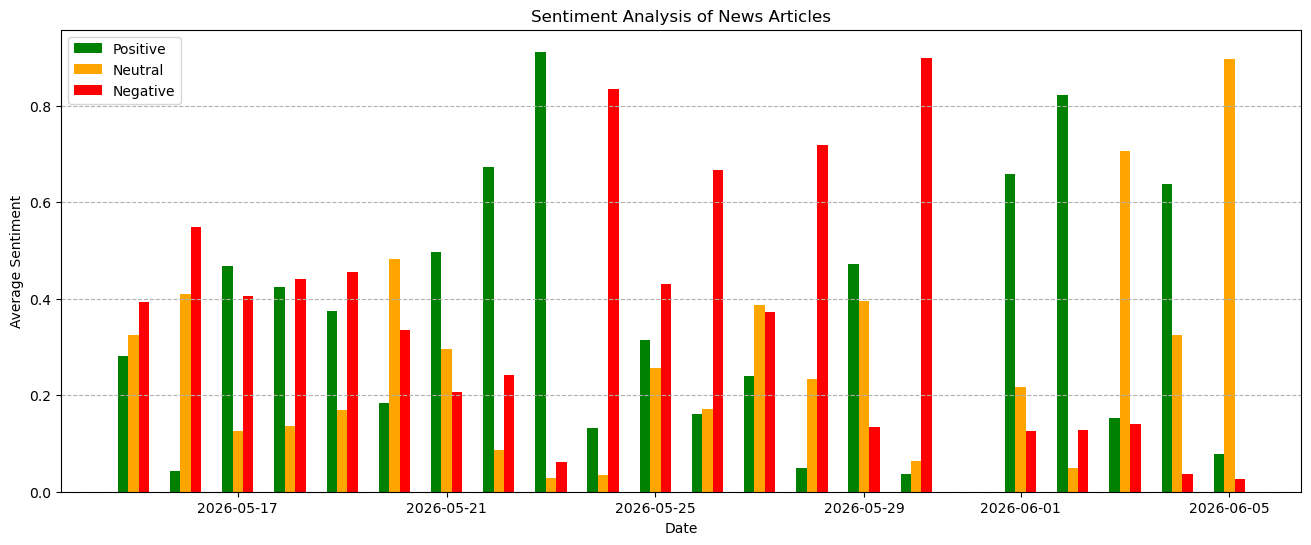

In [5]:
# Group by date and calculate average sentiment scores
df_grouped = df.groupby("Date").agg(["sum", "count"])

# Create new columns for normalized sentiment scores
df_grouped["avg_positive"] = df_grouped["Sent_positive"]["sum"] / df_grouped["Sent_positive"]["count"]  
df_grouped["avg_negative"] = df_grouped["Sent_negative"]["sum"] / df_grouped["Sent_negative"]["count"]  
df_grouped["avg_neutral"] = df_grouped["Sent_neutral"]["sum"] / df_grouped["Sent_neutral"]["count"]  


df_grouped.index = pd.to_datetime(df_grouped.index)

# Plot the sentiment data
fig, ax = plt.subplots(figsize=(16, 6))
width = 0.2
ax.bar(df_grouped.index - pd.DateOffset(days=width), df_grouped["avg_positive"], width=width, label="Positive", color="green")
ax.bar(df_grouped.index, df_grouped["avg_neutral"], width=width, label="Neutral", color="orange")
ax.bar(df_grouped.index + pd.DateOffset(days=width), df_grouped["avg_negative"], width=width, label="Negative", color="red")
ax.set_xlabel("Date")
ax.set_ylabel("Average Sentiment")
ax.set_title("Sentiment Analysis of News Articles")
ax.legend()
ax.grid(True, axis="y", linestyle="--")
plt.show()

## Sentiment Analysis Scores with Stock Price

YF.download() has changed argument auto_adjust default to True


C:\Users\sonny\anaconda3\envs\project_finance\Lib\site-packages\yfinance\scrapers\history.py:173: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed


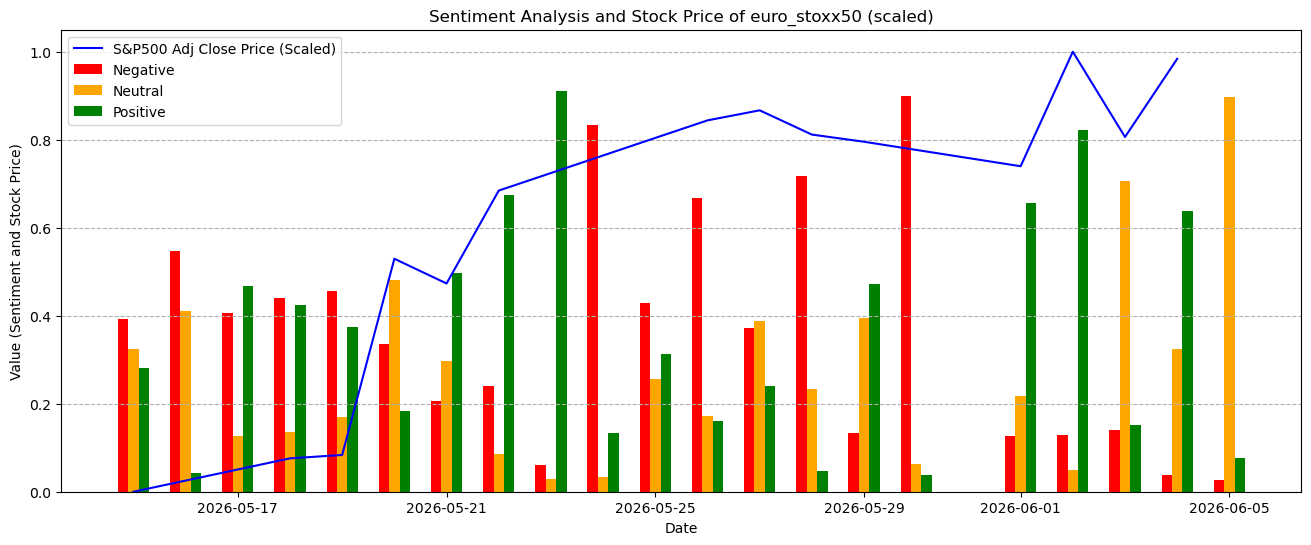

In [6]:
euro_stoxx50 = yf.download("^STOXX50E", start=df_grouped.index.min(), end=df_grouped.index.max())

# Scale the Microsoft price data
scaler = MinMaxScaler()
scaled_stock_price = scaler.fit_transform(euro_stoxx50[["Close"]])

# Plot scaled price plot
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(euro_stoxx50.index, scaled_stock_price, color="blue", label="S&P500 Adj Close Price (Scaled)")

# Plot the sentiment data
width = 0.2  # Adjust the width as needed
ax.bar(df_grouped.index - pd.DateOffset(days=width), df_grouped["avg_negative"], width=width, label="Negative", color="red")
ax.bar(df_grouped.index, df_grouped["avg_neutral"], width=width, label="Neutral", color="orange")
ax.bar(df_grouped.index + pd.DateOffset(days=width), df_grouped["avg_positive"], width=width, label="Positive", color="green")

# Set plot attributes (labels, ticks, title, legend, gridlines)
ax.set_xlabel("Date")
ax.set_title("Sentiment Analysis and Stock Price of euro_stoxx50 (scaled)")
ax.set_ylabel("Value (Sentiment and Stock Price)")
ax.legend()
ax.grid(True, axis="y", linestyle='--')
plt.show()

# Topic Modeling 

## Data Preparation 

In [7]:
df.loc[:, "Processed_Description"] = df["Description"].apply(lambda x: preprocess(x))

## Feature Extraction - Document-Term Matrix 

In [8]:
vectorizer = TfidfVectorizer(max_features=250, stop_words="english")
dtm = vectorizer.fit_transform(df["Processed_Description"])
dtm.shape

(92, 250)

## NMF Application 

In [9]:
nmf_model = NMF(n_components=5, random_state=42) #5 topics
W = nmf_model.fit_transform(dtm)
H = nmf_model.components_

## Topic Extraction and Interpretation 

In [10]:
# Retrieves the names of the features (words)
feature_names = vectorizer.get_feature_names_out()

# Extract top words
n_top_words = 10 
for topic_idx, topic in enumerate(H):
    print(f"\nTopic {topic_idx + 1}:")
    print(" ".join([feature_names[i]
                    for i in topic.argsort()[:-n_top_words - 1:-1]]))


Topic 1:
nifty sensex markets stock indian highlights 23 50 iran market

Topic 2:
oil deal climbed ceasefire intelligence artificial investors trade powered iran

Topic 3:
crypto trading post world eu appeared platform european landmark assets

Topic 4:
market ai amid global investors economic stocks jones dow concerns

Topic 5:
euronext results amsterdam 2026 athens year exchange milan paris oslo


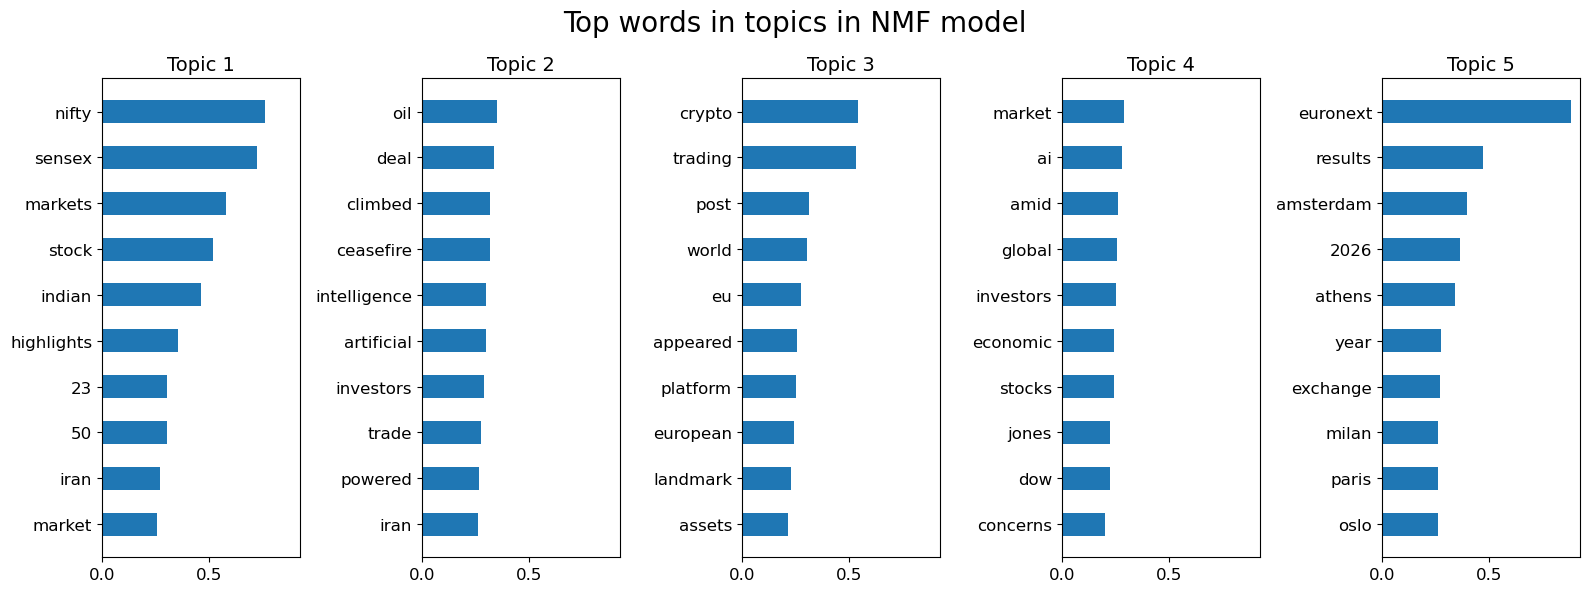

In [11]:
fig, axes = plt.subplots(1, nmf_model.n_components, figsize=(16, 6), sharex=True)
axes = axes.flatten()  # Convert to 1D array for easier indexing

# Plot bar subplots for each topic
for topic_idx, topic in enumerate(H):
    top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
    top_features = [feature_names[i] for i in top_features_ind]
    weights = topic[top_features_ind]

    ax = axes[topic_idx]
    ax.barh(top_features, weights, height=0.5, fill="blue")
    ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 14})
    ax.invert_yaxis()
    ax.tick_params(axis="both", which="major", labelsize=12)

fig.suptitle("Top words in topics in NMF model", fontsize=20, y=0.98)
fig.tight_layout(h_pad=2.0)
plt.show()

**Topic 1 : Indian & Middle Eastern Market**
- Top words : `nifty, sensex, markets, stock, indian, highlights, 23, 50, iran, market`
- Interpretation : This topic covers financial market news from India (Nifty, Sensex) and the Middle East (Iran). It likely consists of daily market summaries from Asian and emerging markets.

**Topic 2 : Geopolitical Events & Commodity Markets**
- Top words : `oil, deal, climbed, ceasefire, intelligence, artificial, investors, trade, powered, iran`
- Interpretation : This topic groups geopolitical news (ceasefire, Iran) and their impact on commodity markets, particularly oil. AI as an analytical tool is also mentioned.

**Topic 3 : European Crypto & Digital Assets Regulation**
- Top words : `crypto, trading, post, world, eu, appeared, platform, european, landmark, assets`
- Interpretation : This topic covers European regulation of crypto-assets and digital trading platforms, likely related to MiCA or other EU legislative initiatives.

**Topic 4 : Global Market Uncertainty & AI**
- Top words : `market, ai, amid, global, investors, economic, stocks, jones, dow, concerns`
- Interpretation : This topic reflects investor concerns around global economic uncertainty, with growing mentions of AI in equity markets. The Dow Jones is cited as a key reference index.

**Topic 5 : Euronext & European Exchange Results**
- Top words : `euronext, results, amsterdam, 2026, athens, year, exchange, milan, paris, oslo`
- Interpretation : This topic is directly linked to European stock exchange news — Euronext Paris, Amsterdam, Milan, Oslo, Athens — and their 2026 financial results.

## Document-Topic Assignement

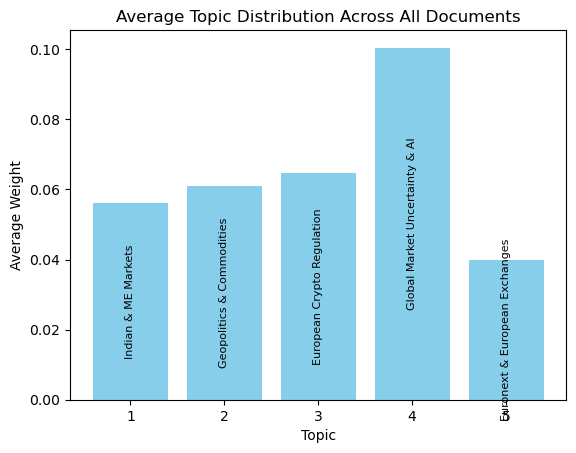

In [12]:
# Assigns the dominant topic for each document
df["Dominant_Topic"] = W.argmax(axis=1) + 1 

# Visualize average topic distribution across all documents
avg_topic_distribution = W.mean(axis=0)

# Define topic labels
topic_labels = [
    "Indian & ME Markets",
    "Geopolitics & Commodities", 
    "European Crypto Regulation",
    "Global Market Uncertainty & AI",
    "Euronext & European Exchanges"
]

# Create bar plot
bars = plt.bar(np.arange(nmf_model.n_components) + 1, avg_topic_distribution, color="skyblue")

# Add bar labels inside bars
for bar, label in zip(bars, topic_labels):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, label,
             ha="center", va="center", rotation=90, color="black", fontsize=8)

plt.xticks(np.arange(nmf_model.n_components) + 1)
plt.xlabel("Topic")
plt.ylabel("Average Weight")
plt.title("Average Topic Distribution Across All Documents")
plt.show()